<a href="https://colab.research.google.com/github/Storm00212/Data-science-and-ml-resource/blob/main/Simple_snn_framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# =============================================
# Simple Spiking Neural Network (SNN) in Google Colab
# Using snnTorch + PyTorch on MNIST (rate-coded)
# =============================================

# 1. Install dependencies
!pip install snntorch torchvision matplotlib -q

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import snntorch as snn
from snntorch import spikegen, spikeplot as splt
from snntorch import functional as SF

import matplotlib.pyplot as plt
import numpy as np
import itertools

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =============================================
# 2. Load MNIST data and encode to spikes (rate coding)
# =============================================
batch_size = 128
data_path = './data/mnist'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(data_path, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(data_path, train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

# Spike encoding parameters
num_steps = 25  # time steps (simulation length)

# =============================================
# 3. Define a simple Feedforward SNN
# =============================================
class Net(nn.Module):
    def __init__(self, num_inputs=784, num_hidden=128, num_outputs=10, beta=0.95):
        super().__init__()

        # Layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)

        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):
        # x shape: (batch, num_steps, features) or we'll handle it inside

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        spk2_rec = []  # record output spikes
        mem2_rec = []  # record output membrane

        for step in range(num_steps):
            cur1 = self.fc1(x[step])          # input at time step
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

net = Net().to(device)

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 145MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 51.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 109MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.79MB/s]


In [10]:
# =============================================
# 4. Training Loop
# =============================================
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))
loss_fn = SF.ce_rate_loss()  # Cross-entropy on spike rate

num_epochs = 3  # keep small for demo; increase for better results

train_loss_hist = []
train_acc_hist = []

print("Starting training...")

for epoch in range(num_epochs):
    net.train()
    epoch_loss = 0
    epoch_acc = 0
    for data, targets in itertools.islice(train_loader, 200):  # limit batches for speed in demo
        data = data.to(device)           # (batch, 1, 28, 28)
        targets = targets.to(device)

        # Flatten and encode to spikes over time: (num_steps, batch, features)
        data = spikegen.rate(data.view(data.size(0), -1), num_steps=num_steps)

        spk_rec, _ = net(data)

        loss = loss_fn(spk_rec, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # Accuracy: highest spike count wins
        _, predicted = spk_rec.sum(dim=0).max(1)
        epoch_acc += (predicted == targets).float().mean().item()

    train_loss_hist.append(epoch_loss / len(train_loader))
    train_acc_hist.append(epoch_acc / len(train_loader))
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss_hist[-1]:.4f} - Acc: {train_acc_hist[-1]:.4f}")

Starting training...
Epoch 1/3 - Loss: 0.7295 - Acc: 0.3537
Epoch 2/3 - Loss: 0.6716 - Acc: 0.3912
Epoch 3/3 - Loss: 0.6616 - Acc: 0.3977


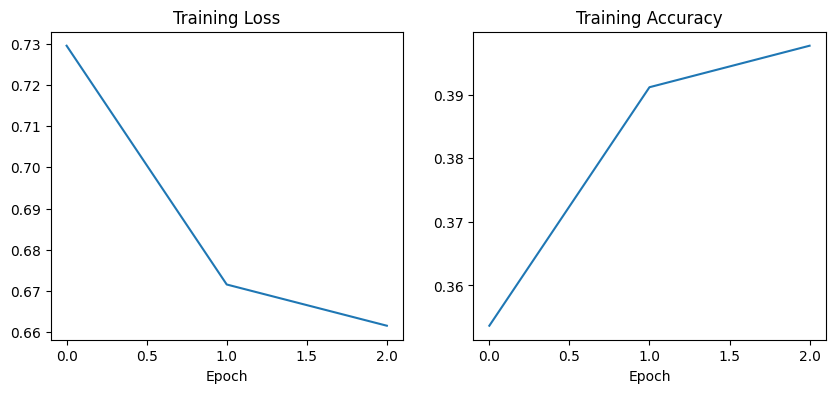

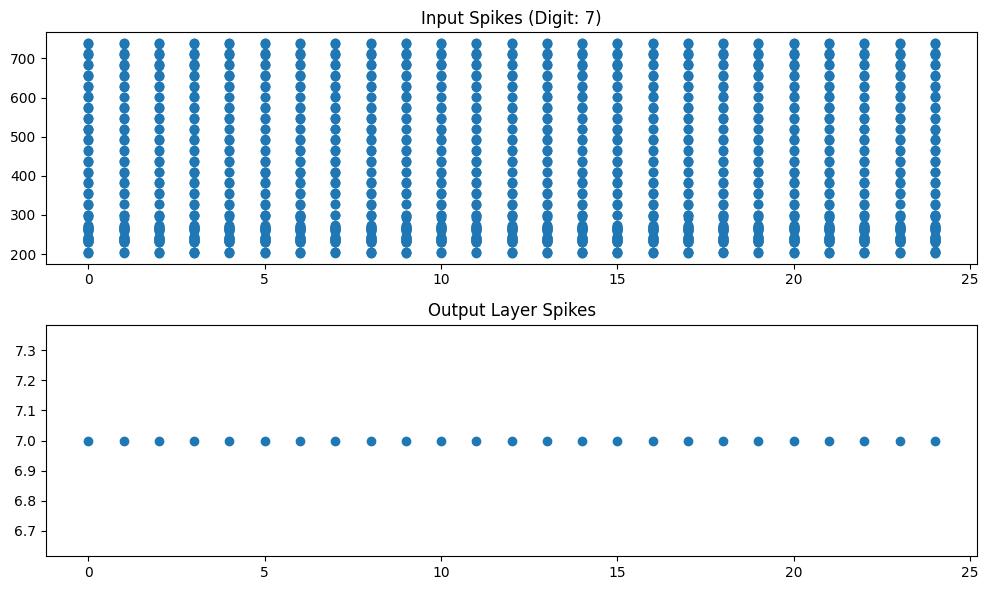

Test Accuracy: 92.41%


In [11]:
# =============================================
# 5. Visualization
# =============================================

# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_hist)
plt.title("Training Loss")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(train_acc_hist)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.show()

# Visualize spikes for one sample
net.eval()
with torch.no_grad():
    data, target = next(iter(test_loader))
    data = data[0:1].to(device)  # one sample
    data_flat = data.view(1, -1)
    spike_in = spikegen.rate(data_flat, num_steps=num_steps)

    spk_rec, mem_rec = net(spike_in)

    # Input raster
    fig, ax = plt.subplots(2, 1, figsize=(10, 6))
    splt.raster(spike_in[:, 0], ax[0])
    ax[0].set_title(f"Input Spikes (Digit: {target[0].item()})")

    # Output membrane / spikes
    splt.raster(spk_rec[:, 0], ax[1])
    ax[1].set_title("Output Layer Spikes")
    plt.tight_layout()
    plt.show()

# Test accuracy
net.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, targets in itertools.islice(test_loader, 50):  # quick test
        data = data.to(device)
        targets = targets.to(device)
        data = spikegen.rate(data.view(data.size(0), -1), num_steps=num_steps)

        spk_rec, _ = net(data)
        _, predicted = spk_rec.sum(dim=0).max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")